# TinyLoRA 拡張実験

TinyLoRA を発展させると W exp(k_1 A_1)  の形で書ける。

これは W exp(k_1 A_1) exp(k_2 A_2) のように拡張できる。

ここで A_i はランダム行列でもよいので、逆に「基底」を共有して、各重み W ごとに係数 k_i だけを学習するという方向が考えられる。さらに A_i 自体も、k_i より遅いスケールで学習する（メタ的に更新する）こともできる。

これは LoRA とは異なる「乗法的な変換」の軸になっている。

したがって

W_{eff} = W_0 exp(sum_i k_i A_i) + B_t C_t

のように、LoRA（加法）と組み合わせることができる。

実験すると、

・LoRA的なデータでは LoRA が効く

・指数型の構造がある場合はこちらが効く

・混合の場合はハイブリッドが最も良い

という結果になった。

直感的には「ax + b」の非線形版（乗法 + 加法）になっており、少ないパラメータで広い変形を表現できる可能性がある。

ChatGPTとの議論：

https://chatgpt.com/share/69e3afc7-3e0c-83e8-94f6-f26100c77992

解説記事:

http://jrf.cocolog-nifty.com/statuses/2026/03/post-b22b37.html

Device: cpu

Parameter budgets
  Oracle shared-exp:      60
  Random shared-exp:      60
  Learnable shared-exp:   3,132
  LoRA per-task rank 4:   5,120

Training oracle shared basis model...
[SharedExp] step  300/1500  loss=0.000286
[SharedExp] step  600/1500  loss=0.000101
[SharedExp] step  900/1500  loss=0.000100
[SharedExp] step 1200/1500  loss=0.000100
[SharedExp] step 1500/1500  loss=0.000100

Training random shared basis model...
[SharedExp] step  300/1500  loss=0.012278
[SharedExp] step  600/1500  loss=0.012278
[SharedExp] step  900/1500  loss=0.012278
[SharedExp] step 1200/1500  loss=0.012278
[SharedExp] step 1500/1500  loss=0.012278

Training learnable shared basis model...
[SharedExp] step  300/1500  loss=0.000238
[SharedExp] step  600/1500  loss=0.000145
[SharedExp] step  900/1500  loss=0.000130
[SharedExp] step 1200/1500  loss=0.000126
[SharedExp] step 1500/1500  loss=0.000123

Training LoRA baseline...
[LoRA]     step  300/1500  loss=0.005893
[LoRA]     step  600/1500  lo

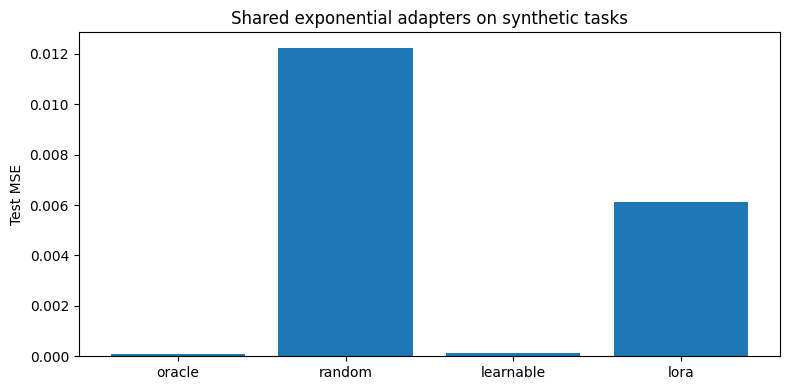

In [ ]:
"""Synthetic experiment for shared exponential adapters.

Idea under test
---------------
A frozen base weight W0 is adapted by a product of exponentials:

    W_eff = W0 @ exp(k1 * A1) @ exp(k2 * A2) ...

Across many tasks, the A_i are shared. Each task learns only the scalar
coefficients k_i. Optionally, A_i can be learned slowly later.

This script builds a synthetic benchmark where the data are generated by the
same factorization, then compares:

1) Oracle shared-basis model (learn k per task; A fixed to the true basis)
2) Random shared-basis model (learn k per task; A fixed random)
3) Learnable shared-basis model (learn both A and k)
4) LoRA baseline (per-task low-rank additive adapter)

The benchmark is intentionally small and controlled so you can verify whether
"basis sharing + coefficient-only task adaptation" is viable before moving to a
real Transformer layer.

Requirements
------------
- Python 3.10+
- PyTorch
- matplotlib (optional, only for plotting)

Run
---
    python shared_exponential_adapter_experiment.py

You can adjust the constants in main() for bigger/smaller runs.
"""

from __future__ import annotations

import math
import random
from dataclasses import dataclass
from typing import List, Tuple, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F


# -----------------------------
# Utilities
# -----------------------------


def set_seed(seed: int = 0) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def make_orthogonal_basis(d: int, m: int, device: torch.device) -> torch.Tensor:
    """Return m orthonormal-ish basis matrices flattened from random Gaussian init.

    The matrices are shaped [m, d, d]. We orthonormalize their flattened vectors
    and then reshape back. This gives a nicely conditioned synthetic generator.
    """
    x = torch.randn(m, d * d, device=device)
    q, _ = torch.linalg.qr(x.T, mode="reduced")  # [d*d, m]
    basis = q.T.reshape(m, d, d).contiguous()
    return basis


def exp_product(A_list: torch.Tensor, k: torch.Tensor) -> torch.Tensor:
    """Compute product_i exp(k_i * A_i).

    Args:
        A_list: [m, d, d]
        k: [m]
    Returns:
        Transform matrix [d, d]
    """
    assert A_list.ndim == 3
    assert k.ndim == 1 and k.shape[0] == A_list.shape[0]

    d = A_list.shape[-1]
    out = torch.eye(d, device=A_list.device, dtype=A_list.dtype)
    for i in range(A_list.shape[0]):
        out = out @ torch.matrix_exp(k[i] * A_list[i])
    return out


def generate_task_weights(
    W0: torch.Tensor,
    A_shared: torch.Tensor,
    k_task: torch.Tensor,
) -> torch.Tensor:
    """W_task = W0 @ product_i exp(k_i A_i)."""
    return W0 @ exp_product(A_shared, k_task)


def sample_linear_data(
    W_task: torch.Tensor,
    n: int,
    noise_std: float,
    device: torch.device,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """Generate x ~ N(0, I), y = x @ W_task^T + noise."""
    d = W_task.shape[0]
    x = torch.randn(n, d, device=device)
    y = x @ W_task.T
    if noise_std > 0:
        y = y + noise_std * torch.randn_like(y)
    return x, y


# -----------------------------
# Models
# -----------------------------


class SharedExpAdapter(nn.Module):
    """Shared basis exponential adapter.

    Base matrix W0 is frozen. A_i are either frozen or learnable.
    Each task t has its own coefficient vector k_t.
    """

    def __init__(
        self,
        W0: torch.Tensor,
        num_tasks: int,
        num_basis: int,
        learn_basis: bool = False,
        basis_init: torch.Tensor | None = None,
    ) -> None:
        super().__init__()
        self.register_buffer("W0", W0.clone().detach())
        d = W0.shape[0]

        if basis_init is None:
            A = torch.randn(num_basis, d, d) * 0.05
        else:
            A = basis_init.clone().detach()
        if learn_basis:
            self.A = nn.Parameter(A)
        else:
            self.register_buffer("A", A)

        # Task-specific coefficients.
        self.k = nn.Parameter(torch.zeros(num_tasks, num_basis))

    def forward(self, task_id: int) -> torch.Tensor:
        A = self.A
        k = self.k[task_id]
        T = exp_product(A, k)
        return self.W0 @ T

    def predict(self, task_id: int, x: torch.Tensor) -> torch.Tensor:
        W = self.forward(task_id)
        return x @ W.T


class LoRALinearTaskAdapter(nn.Module):
    """A simple per-task LoRA-style additive adapter.

    W_eff = W0 + B_t @ C_t, where rank = r.
    Each task gets its own low-rank factorization.
    """

    def __init__(self, W0: torch.Tensor, num_tasks: int, rank: int) -> None:
        super().__init__()
        self.register_buffer("W0", W0.clone().detach())
        d_out, d_in = W0.shape
        self.rank = rank
        self.B = nn.Parameter(torch.randn(num_tasks, d_out, rank) * 0.01)
        self.C = nn.Parameter(torch.randn(num_tasks, rank, d_in) * 0.01)

    def forward(self, task_id: int) -> torch.Tensor:
        return self.W0 + self.B[task_id] @ self.C[task_id]

    def predict(self, task_id: int, x: torch.Tensor) -> torch.Tensor:
        W = self.forward(task_id)
        return x @ W.T


# -----------------------------
# Training / evaluation
# -----------------------------


@dataclass
class TaskData:
    x_train: torch.Tensor
    y_train: torch.Tensor
    x_test: torch.Tensor
    y_test: torch.Tensor


def build_dataset(
    W0: torch.Tensor,
    A_true: torch.Tensor,
    num_tasks: int,
    num_train: int,
    num_test: int,
    noise_std: float,
    k_scale: float,
    device: torch.device,
) -> Tuple[List[TaskData], torch.Tensor]:
    """Create tasks from the same shared exponential family.

    Returns:
        tasks: list of per-task train/test tensors
        k_true: [num_tasks, num_basis]
    """
    num_basis = A_true.shape[0]
    k_true = torch.randn(num_tasks, num_basis, device=device) * k_scale
    tasks: List[TaskData] = []
    for t in range(num_tasks):
        W_t = generate_task_weights(W0, A_true, k_true[t])
        x_train, y_train = sample_linear_data(W_t, num_train, noise_std, device)
        x_test, y_test = sample_linear_data(W_t, num_test, noise_std, device)
        tasks.append(TaskData(x_train, y_train, x_test, y_test))
    return tasks, k_true


@torch.no_grad()
def eval_model(model: nn.Module, tasks: List[TaskData], kind: str) -> Dict[str, float]:
    model.eval()
    train_losses = []
    test_losses = []
    for t, task in enumerate(tasks):
        pred_train = model.predict(t, task.x_train)
        pred_test = model.predict(t, task.x_test)
        train_losses.append(F.mse_loss(pred_train, task.y_train).item())
        test_losses.append(F.mse_loss(pred_test, task.y_test).item())
    return {
        f"{kind}/train_mse": float(sum(train_losses) / len(train_losses)),
        f"{kind}/test_mse": float(sum(test_losses) / len(test_losses)),
    }


def train_shared_exp(
    model: SharedExpAdapter,
    tasks: List[TaskData],
    steps: int,
    lr: float,
    weight_decay: float = 0.0,
    basis_lr_mult: float = 1.0,
) -> None:
    params = []
    if hasattr(model, "A") and isinstance(model.A, nn.Parameter):
        params.append({"params": [model.A], "lr": lr * basis_lr_mult})
    params.append({"params": [model.k], "lr": lr})
    opt = torch.optim.AdamW(params, weight_decay=weight_decay)

    num_tasks = len(tasks)
    for step in range(steps):
        opt.zero_grad(set_to_none=True)
        loss = 0.0
        for t in range(num_tasks):
            task = tasks[t]
            pred = model.predict(t, task.x_train)
            loss = loss + F.mse_loss(pred, task.y_train)
        loss = loss / num_tasks
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if (step + 1) % max(1, steps // 5) == 0:
            print(f"[SharedExp] step {step+1:4d}/{steps}  loss={loss.item():.6f}")


def train_lora(
    model: LoRALinearTaskAdapter,
    tasks: List[TaskData],
    steps: int,
    lr: float,
    weight_decay: float = 0.0,
) -> None:
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    num_tasks = len(tasks)
    for step in range(steps):
        opt.zero_grad(set_to_none=True)
        loss = 0.0
        for t in range(num_tasks):
            task = tasks[t]
            pred = model.predict(t, task.x_train)
            loss = loss + F.mse_loss(pred, task.y_train)
        loss = loss / num_tasks
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if (step + 1) % max(1, steps // 5) == 0:
            print(f"[LoRA]     step {step+1:4d}/{steps}  loss={loss.item():.6f}")


def parameter_count(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


# -----------------------------
# Main experiment
# -----------------------------


def main() -> None:
    set_seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # Problem size.
    d = 32
    num_basis = 3
    num_tasks = 20
    num_train = 512
    num_test = 512
    noise_std = 0.01
    k_scale = 0.35

    # Training settings.
    steps = 1500
    lr = 3e-3
    wd = 0.0

    # Base model and true basis.
    W0 = torch.randn(d, d, device=device) / math.sqrt(d)
    A_true = make_orthogonal_basis(d, num_basis, device)

    tasks, k_true = build_dataset(
        W0=W0,
        A_true=A_true,
        num_tasks=num_tasks,
        num_train=num_train,
        num_test=num_test,
        noise_std=noise_std,
        k_scale=k_scale,
        device=device,
    )

    print("\nParameter budgets")
    oracle = SharedExpAdapter(W0, num_tasks=num_tasks, num_basis=num_basis, learn_basis=False, basis_init=A_true)
    random_basis = SharedExpAdapter(W0, num_tasks=num_tasks, num_basis=num_basis, learn_basis=False)
    learnable_basis = SharedExpAdapter(W0, num_tasks=num_tasks, num_basis=num_basis, learn_basis=True)
    lora = LoRALinearTaskAdapter(W0, num_tasks=num_tasks, rank=4)
    print(f"  Oracle shared-exp:      {parameter_count(oracle):,}")
    print(f"  Random shared-exp:      {parameter_count(random_basis):,}")
    print(f"  Learnable shared-exp:   {parameter_count(learnable_basis):,}")
    print(f"  LoRA per-task rank 4:   {parameter_count(lora):,}")

    # 1) Oracle basis: only k learned.
    print("\nTraining oracle shared basis model...")
    train_shared_exp(oracle, tasks, steps=steps, lr=lr, weight_decay=wd)
    oracle_metrics = eval_model(oracle, tasks, "oracle")

    # 2) Random basis: only k learned.
    print("\nTraining random shared basis model...")
    train_shared_exp(random_basis, tasks, steps=steps, lr=lr, weight_decay=wd)
    random_metrics = eval_model(random_basis, tasks, "random_basis")

    # 3) Learnable basis: A and k learned.
    print("\nTraining learnable shared basis model...")
    train_shared_exp(
        learnable_basis,
        tasks,
        steps=steps,
        lr=lr,
        weight_decay=wd,
        basis_lr_mult=0.25,
    )
    learnable_metrics = eval_model(learnable_basis, tasks, "learnable_basis")

    # 4) LoRA baseline.
    print("\nTraining LoRA baseline...")
    train_lora(lora, tasks, steps=steps, lr=lr, weight_decay=wd)
    lora_metrics = eval_model(lora, tasks, "lora")

    # Summarize.
    print("\n=== Results ===")
    results = {}
    results.update(oracle_metrics)
    results.update(random_metrics)
    results.update(learnable_metrics)
    results.update(lora_metrics)
    for k, v in results.items():
        print(f"{k:28s}: {v:.8f}")

    # A small diagnostic: correlation between learned k and true k.
    with torch.no_grad():
        true_k = k_true.flatten()
        learned_k = oracle.k.detach().flatten()
        corr = torch.corrcoef(torch.stack([true_k, learned_k]))[0, 1].item()
        print(f"\nOracle basis k-correlation with ground truth: {corr:.4f}")

    # Optional plot.
    try:
        import matplotlib.pyplot as plt

        labels = ["oracle", "random", "learnable", "lora"]
        vals = [
            oracle_metrics["oracle/test_mse"],
            random_metrics["random_basis/test_mse"],
            learnable_metrics["learnable_basis/test_mse"],
            lora_metrics["lora/test_mse"],
        ]
        plt.figure(figsize=(8, 4))
        plt.bar(labels, vals)
        plt.ylabel("Test MSE")
        plt.title("Shared exponential adapters on synthetic tasks")
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Plot skipped: {e}")


if __name__ == "__main__":
    main()


In [ ]:
"""Out-of-hypothesis (mismatch) experiments for shared exponential adapters.

Goal
----
Test robustness when the data are NOT generated by the shared exponential
family used by the model. We construct several generators:

A) Additive low-rank (LoRA-like):      W = W0 + U_t V_t
B) Unconstrained full matrix:          W sampled freely around W0
C) Mixed:                              W = W0 @ exp(kA) + (U_t V_t)

We compare:
- SharedExp (random basis, k-only)
- SharedExp (learnable basis + k)
- LoRA baseline (per-task low-rank)

This isolates when your method fails or degrades compared to LoRA.

Run
---
    python shared_exponential_adapter_mismatch_experiment.py
"""

from __future__ import annotations

import math
import random
from dataclasses import dataclass
from typing import List, Tuple, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F


# -----------------------------
# Utilities
# -----------------------------


def set_seed(seed: int = 0) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def exp_product(A_list: torch.Tensor, k: torch.Tensor) -> torch.Tensor:
    d = A_list.shape[-1]
    out = torch.eye(d, device=A_list.device, dtype=A_list.dtype)
    for i in range(A_list.shape[0]):
        out = out @ torch.matrix_exp(k[i] * A_list[i])
    return out


def sample_linear_data(W: torch.Tensor, n: int, noise_std: float, device: torch.device):
    d = W.shape[0]
    x = torch.randn(n, d, device=device)
    y = x @ W.T
    if noise_std > 0:
        y = y + noise_std * torch.randn_like(y)
    return x, y


# -----------------------------
# Generators (mismatch cases)
# -----------------------------


def gen_lora_like(W0, rank, scale, device):
    d = W0.shape[0]
    U = torch.randn(d, rank, device=device) * scale
    V = torch.randn(rank, d, device=device) * scale
    return W0 + U @ V


def gen_full_random(W0, scale, device):
    d = W0.shape[0]
    return W0 + torch.randn(d, d, device=device) * scale


def gen_mixed(W0, A_shared, k, rank, scale, device):
    W_exp = W0 @ exp_product(A_shared, k)
    d = W0.shape[0]
    U = torch.randn(d, rank, device=device) * scale
    V = torch.randn(rank, d, device=device) * scale
    return W_exp + U @ V


# -----------------------------
# Models
# -----------------------------


class SharedExp(nn.Module):
    def __init__(self, W0, num_tasks, num_basis, learn_basis=False):
        super().__init__()
        self.register_buffer("W0", W0.clone().detach())
        d = W0.shape[0]
        A = torch.randn(num_basis, d, d) * 0.05
        if learn_basis:
            self.A = nn.Parameter(A)
        else:
            self.register_buffer("A", A)
        self.k = nn.Parameter(torch.zeros(num_tasks, num_basis))

    def forward(self, t):
        return self.W0 @ exp_product(self.A, self.k[t])

    def predict(self, t, x):
        return x @ self.forward(t).T


class LoRA(nn.Module):
    def __init__(self, W0, num_tasks, rank):
        super().__init__()
        self.register_buffer("W0", W0.clone().detach())
        d = W0.shape[0]
        self.B = nn.Parameter(torch.randn(num_tasks, d, rank) * 0.01)
        self.C = nn.Parameter(torch.randn(num_tasks, rank, d) * 0.01)

    def forward(self, t):
        return self.W0 + self.B[t] @ self.C[t]

    def predict(self, t, x):
        return x @ self.forward(t).T


# -----------------------------
# Dataset
# -----------------------------


@dataclass
class Task:
    x_tr: torch.Tensor
    y_tr: torch.Tensor
    x_te: torch.Tensor
    y_te: torch.Tensor


def build_tasks(kind, W0, num_tasks, n_tr, n_te, device):
    tasks = []
    d = W0.shape[0]
    A_shared = torch.randn(3, d, d, device=device) * 0.05

    for _ in range(num_tasks):
        if kind == "lora":
            W = gen_lora_like(W0, rank=4, scale=0.2, device=device)
        elif kind == "full":
            W = gen_full_random(W0, scale=0.2, device=device)
        elif kind == "mixed":
            k = torch.randn(3, device=device) * 0.3
            W = gen_mixed(W0, A_shared, k, rank=2, scale=0.1, device=device)
        else:
            raise ValueError(kind)

        x_tr, y_tr = sample_linear_data(W, n_tr, 0.01, device)
        x_te, y_te = sample_linear_data(W, n_te, 0.01, device)
        tasks.append(Task(x_tr, y_tr, x_te, y_te))
    return tasks


# -----------------------------
# Train / eval
# -----------------------------


def train(model, tasks, steps=1000, lr=3e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for step in range(steps):
        opt.zero_grad()
        loss = 0
        for t, task in enumerate(tasks):
            pred = model.predict(t, task.x_tr)
            loss += F.mse_loss(pred, task.y_tr)
        loss /= len(tasks)
        loss.backward()
        opt.step()
    return model


@torch.no_grad()
def evaluate(model, tasks):
    loss = 0
    for t, task in enumerate(tasks):
        pred = model.predict(t, task.x_te)
        loss += F.mse_loss(pred, task.y_te)
    return (loss / len(tasks)).item()


# -----------------------------
# Main
# -----------------------------


def run_case(kind):
    device = torch.device("cpu")
    d = 32
    W0 = torch.randn(d, d, device=device) / math.sqrt(d)

    tasks = build_tasks(kind, W0, num_tasks=20, n_tr=512, n_te=512, device=device)

    m1 = SharedExp(W0, 20, 3, learn_basis=False)
    m2 = SharedExp(W0, 20, 3, learn_basis=True)
    m3 = LoRA(W0, 20, rank=4)

    train(m1, tasks)
    train(m2, tasks)
    train(m3, tasks)

    return {
        "shared_fixed": evaluate(m1, tasks),
        "shared_learned": evaluate(m2, tasks),
        "lora": evaluate(m3, tasks),
    }


def main():
    set_seed(0)
    for kind in ["lora", "full", "mixed"]:
        res = run_case(kind)
        print(f"\n=== {kind} generator ===")
        for k, v in res.items():
            print(f"{k:16s}: {v:.6f}")


if __name__ == "__main__":
    main()



=== lora generator ===
shared_fixed    : 0.195721
shared_learned  : 0.135113
lora            : 0.000101

=== full generator ===
shared_fixed    : 1.266396
shared_learned  : 0.992556
lora            : 0.797024

=== mixed generator ===
shared_fixed    : 0.028990
shared_learned  : 0.005412
lora            : 0.013022


In [ ]:
"""Hybrid exponential + LoRA experiment.

Model:
    W_eff = W0 @ exp(sum_i k_i A_i) + B_t @ C_t

Rationale:
- exp part captures multiplicative / manifold-like structure
- LoRA part captures additive residual corrections

This script evaluates the hybrid on three synthetic generators:
1) LoRA-like additive data
2) Full random data
3) Mixed data: exp structure + additive low-rank residual

It compares:
- SharedExp (fixed basis)
- SharedExp (learnable basis)
- LoRA
- HybridExpLoRA (the proposed combined model)

Run:
    python hybrid_exponential_lora_experiment.py
"""

from __future__ import annotations

import math
import random
from dataclasses import dataclass
from typing import List, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F


# -----------------------------
# Utilities
# -----------------------------


def set_seed(seed: int = 0) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def make_basis(d: int, m: int, device: torch.device) -> torch.Tensor:
    x = torch.randn(m, d * d, device=device)
    q, _ = torch.linalg.qr(x.T, mode="reduced")
    return q.T.reshape(m, d, d).contiguous()


def exp_product(A_list: torch.Tensor, k: torch.Tensor) -> torch.Tensor:
    d = A_list.shape[-1]
    out = torch.eye(d, device=A_list.device, dtype=A_list.dtype)
    for i in range(A_list.shape[0]):
        out = out @ torch.matrix_exp(k[i] * A_list[i])
    return out


def sample_linear_data(W: torch.Tensor, n: int, noise_std: float, device: torch.device):
    d = W.shape[0]
    x = torch.randn(n, d, device=device)
    y = x @ W.T
    if noise_std > 0:
        y = y + noise_std * torch.randn_like(y)
    return x, y


# -----------------------------
# Data generators
# -----------------------------


def gen_lora_like(W0, rank, scale, device):
    d = W0.shape[0]
    U = torch.randn(d, rank, device=device) * scale
    V = torch.randn(rank, d, device=device) * scale
    return W0 + U @ V


def gen_full_random(W0, scale, device):
    d = W0.shape[0]
    return W0 + torch.randn(d, d, device=device) * scale


def gen_mixed(W0, A_shared, k, rank, scale, device):
    W_exp = W0 @ exp_product(A_shared, k)
    d = W0.shape[0]
    U = torch.randn(d, rank, device=device) * scale
    V = torch.randn(rank, d, device=device) * scale
    return W_exp + U @ V


# -----------------------------
# Models
# -----------------------------


class SharedExp(nn.Module):
    def __init__(self, W0, num_tasks, num_basis, learn_basis=False):
        super().__init__()
        self.register_buffer("W0", W0.clone().detach())
        d = W0.shape[0]
        A = torch.randn(num_basis, d, d) * 0.05
        if learn_basis:
            self.A = nn.Parameter(A)
        else:
            self.register_buffer("A", A)
        self.k = nn.Parameter(torch.zeros(num_tasks, num_basis))

    def forward(self, t):
        return self.W0 @ exp_product(self.A, self.k[t])

    def predict(self, t, x):
        return x @ self.forward(t).T


class LoRA(nn.Module):
    def __init__(self, W0, num_tasks, rank):
        super().__init__()
        self.register_buffer("W0", W0.clone().detach())
        d = W0.shape[0]
        self.B = nn.Parameter(torch.randn(num_tasks, d, rank) * 0.01)
        self.C = nn.Parameter(torch.randn(num_tasks, rank, d) * 0.01)

    def forward(self, t):
        return self.W0 + self.B[t] @ self.C[t]

    def predict(self, t, x):
        return x @ self.forward(t).T


class HybridExpLoRA(nn.Module):
    """W_eff = W0 @ exp(sum_i k_i A_i) + B_t @ C_t"""

    def __init__(self, W0, num_tasks, num_basis, rank, learn_basis=False):
        super().__init__()
        self.register_buffer("W0", W0.clone().detach())
        d = W0.shape[0]

        A = torch.randn(num_basis, d, d) * 0.05
        if learn_basis:
            self.A = nn.Parameter(A)
        else:
            self.register_buffer("A", A)

        self.k = nn.Parameter(torch.zeros(num_tasks, num_basis))
        self.B = nn.Parameter(torch.randn(num_tasks, d, rank) * 0.01)
        self.C = nn.Parameter(torch.randn(num_tasks, rank, d) * 0.01)

    def forward(self, t):
        exp_part = self.W0 @ exp_product(self.A, self.k[t])
        lora_part = self.B[t] @ self.C[t]
        return exp_part + lora_part

    def predict(self, t, x):
        return x @ self.forward(t).T


# -----------------------------
# Tasks
# -----------------------------


@dataclass
class Task:
    x_tr: torch.Tensor
    y_tr: torch.Tensor
    x_te: torch.Tensor
    y_te: torch.Tensor


def build_tasks(kind, W0, num_tasks, n_tr, n_te, device):
    tasks = []
    d = W0.shape[0]
    A_shared = make_basis(d, 3, device)

    for _ in range(num_tasks):
        if kind == "lora":
            W = gen_lora_like(W0, rank=4, scale=0.2, device=device)
        elif kind == "full":
            W = gen_full_random(W0, scale=0.2, device=device)
        elif kind == "mixed":
            k = torch.randn(3, device=device) * 0.3
            W = gen_mixed(W0, A_shared, k, rank=2, scale=0.1, device=device)
        else:
            raise ValueError(kind)

        x_tr, y_tr = sample_linear_data(W, n_tr, 0.01, device)
        x_te, y_te = sample_linear_data(W, n_te, 0.01, device)
        tasks.append(Task(x_tr, y_tr, x_te, y_te))
    return tasks


# -----------------------------
# Train / eval
# -----------------------------


def train(model, tasks, steps=1000, lr=3e-3, basis_lr_mult=0.25):
    params = []
    if hasattr(model, "A") and isinstance(model.A, nn.Parameter):
        params.append({"params": [model.A], "lr": lr * basis_lr_mult})
    if hasattr(model, "k"):
        params.append({"params": [model.k], "lr": lr})
    if hasattr(model, "B"):
        params.append({"params": [model.B], "lr": lr})
    if hasattr(model, "C"):
        params.append({"params": [model.C], "lr": lr})

    opt = torch.optim.Adam(params)

    for step in range(steps):
        opt.zero_grad(set_to_none=True)
        loss = 0.0
        for t, task in enumerate(tasks):
            pred = model.predict(t, task.x_tr)
            loss = loss + F.mse_loss(pred, task.y_tr)
        loss = loss / len(tasks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if (step + 1) % max(1, steps // 5) == 0:
            print(f"[{model.__class__.__name__}] step {step+1:4d}/{steps}  loss={loss.item():.6f}")


@torch.no_grad()
def evaluate(model, tasks):
    loss = 0.0
    for t, task in enumerate(tasks):
        pred = model.predict(t, task.x_te)
        loss = loss + F.mse_loss(pred, task.y_te)
    return (loss / len(tasks)).item()


def param_count(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# -----------------------------
# Main experiment
# -----------------------------


def run_case(kind: str):
    device = torch.device("cpu")
    d = 32
    W0 = torch.randn(d, d, device=device) / math.sqrt(d)

    tasks = build_tasks(kind, W0, num_tasks=20, n_tr=512, n_te=512, device=device)

    models = {
        "shared_fixed": SharedExp(W0, 20, 3, learn_basis=False),
        "shared_learned": SharedExp(W0, 20, 3, learn_basis=True),
        "lora": LoRA(W0, 20, rank=4),
        "hybrid_fixed": HybridExpLoRA(W0, 20, 3, rank=4, learn_basis=False),
        "hybrid_learned": HybridExpLoRA(W0, 20, 3, rank=4, learn_basis=True),
    }

    results: Dict[str, float] = {}
    print(f"\n=== {kind} generator ===")
    for name, model in models.items():
        print(f"{name:16s} params={param_count(model):,}")
        train(model, tasks, steps=1000, lr=3e-3)
        results[name] = evaluate(model, tasks)
    return results


def main():
    set_seed(0)
    for kind in ["lora", "full", "mixed"]:
        res = run_case(kind)
        print("Results:")
        for k, v in res.items():
            print(f"  {k:16s}: {v:.6f}")


if __name__ == "__main__":
    main()



=== lora generator ===
shared_fixed     params=60
[SharedExp] step  200/1000  loss=0.200679
[SharedExp] step  400/1000  loss=0.200679
[SharedExp] step  600/1000  loss=0.200679
[SharedExp] step  800/1000  loss=0.200679
[SharedExp] step 1000/1000  loss=0.200679
shared_learned   params=3,132
[SharedExp] step  200/1000  loss=0.162092
[SharedExp] step  400/1000  loss=0.146838
[SharedExp] step  600/1000  loss=0.139023
[SharedExp] step  800/1000  loss=0.135292
[SharedExp] step 1000/1000  loss=0.133860
lora             params=5,120
[LoRA] step  200/1000  loss=0.000173
[LoRA] step  400/1000  loss=0.000098
[LoRA] step  600/1000  loss=0.000098
[LoRA] step  800/1000  loss=0.000098
[LoRA] step 1000/1000  loss=0.000098
hybrid_fixed     params=5,180
[HybridExpLoRA] step  200/1000  loss=0.000221
[HybridExpLoRA] step  400/1000  loss=0.000098
[HybridExpLoRA] step  600/1000  loss=0.000098
[HybridExpLoRA] step  800/1000  loss=0.000098
[HybridExpLoRA] step 1000/1000  loss=0.000098
hybrid_learned   params=